# Imports

In [1]:
# Linear Algebra
import numpy as np

# Data Processing
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from brokenaxes import brokenaxes

# Hierarchical clustering
from scipy.cluster.hierarchy import linkage, leaves_list
# Spearman correlation
from scipy.stats import spearmanr

# Paths
import os
data_path = os.path.join('..', 'data')

# Json
import json

# Mygene for gene annotation
import mygene
# Initialize mygene
mg = mygene.MyGeneInfo()

# Color palettes
import matplotlib.colors as mcolors

# Discretize Expression by Percentiles

## Load Data

In [2]:
df = pd.read_pickle(os.path.join(data_path, 'genes_human_cleaned.pkl'))
df.head()

,seq,gene,chr,strand,coord_start,coord_end,canonical,ENC,transcript,median_float,tissueSiteDetailId,amino_acid_seq
0,ATGGCGTCCCCGTCTCGGAGACTGCAGACTAAACCAGTCATTACTT...,ENSG00000000003,X,-,100627107,100636806,True,45.363981,ENST00000373020,"(25.280000686645508, 22.770000457763672, 15.26...","(Adipose_Subcutaneous, Adipose_Visceral_Omentu...",MASPSRRLQTKPVITCFKSVLLIYTFIFWITGVILLAVGIWGKVSL...
1,ATGCTAAAACTGTATGCAATGTTTCTGACTCTCGTTTTTTTGGTCG...,ENSG00000000003,X,-,100627108,100637104,False,38.175250,ENST00000612152,"(1.0399999618530273, 0.8700000047683716, 0.485...","(Adipose_Subcutaneous, Adipose_Visceral_Omentu...",MLKLYAMFLTLVFLVELVAAIVGFVFRHEIKNSFKNNYEKALKQYN...
2,ATGGCAAAGAATCCTCCAGAGAATTGTGAAGACTGTCACATTCTAA...,ENSG00000000005,X,+,100584935,100599885,True,45.428790,ENST00000373031,"(15.739999771118164, 6.639999866485596, 0.0, 0...","(Adipose_Subcutaneous, Adipose_Visceral_Omentu...",MAKNPPENCEDCHILNAEAFKSKKICKSLKICGLVFGILALTLIVL...
3,ATGGCCTCCTTGGAAGTCAGTCGTAGTCCTCGCAGGTCTCGGCGGG...,ENSG00000000419,20,-,50934866,50958550,False,46.773340,ENST00000466152,"(1.0700000524520874, 0.9200000166893005, 0.699...","(Adipose_Subcutaneous, Adipose_Visceral_Omentu...",MASLEVSRSPRRSRRELEVRSPRQNKYSVLLPTYNERENLPLIVWL...
4,ATGGCCTCCTTGGAAGTCAGTCGTAGTCCTCGCAGGTCTCGGCGGG...,ENSG00000000419,20,-,50934866,50958555,False,47.072886,ENST00000371582,"(1.3700000047683716, 1.600000023841858, 1.5449...","(Adipose_Subcutaneous, Adipose_Visceral_Omentu...",MASLEVSRSPRRSRRELEVRSPRQNKYSVLLPTYNERENLPLIVWL...


## Discretize Expression

In [13]:
def discretize_expr_tuples(df, expr_th_perc=[0.25, 0.5, 0.75, 0.9]):
    df = df.copy()
    
    # Keep track of NaN values
    nan_mask = df['median_float'].isna()
    
    # Filter out rows with NaN in 'expr' column for discretization
    df_non_nan = df[~nan_mask].copy()
    
    # Extract tuples from 'expr' column
    tuples_list = df_non_nan['median_float'].tolist()
    
    # Transpose the list of tuples to get lists of same-index elements
    transposed = list(zip(*tuples_list))
    
    # Function to discretize a list of values
    def discretize(values, thresholds):
        percentiles = [p * 100 for p in thresholds]
        bins = np.percentile(values, percentiles)
        bins = bins.tolist()
        labels = ['expr_low25', 'expr_pre25_50', 'expr_pre50_75', 'expr_pre75_90', 'expr_top10']

        # Use numpy digitize to assign each value to a bin
        bin_indices = np.digitize(values, bins, right=True)
        discretized = pd.Series(bin_indices).map(lambda x: labels[x])
        return discretized
    
    # Discretize each list of same-index elements
    discretized_transposed = [discretize(list(col), expr_th_perc) for col in transposed]
    
    # Transpose back to get the list of discretized tuples
    discretized_tuples = list(zip(*discretized_transposed))
    
    # Update the DataFrame with the discretized tuples
    df_non_nan['median'] = discretized_tuples
    
    # Reinsert NaN values back into their original positions
    df.loc[~nan_mask, 'median'] = df_non_nan['median']
    
    return df

In [14]:
discretized_df = discretize_expr_tuples(df)

# Save Data

In [15]:
discretized_df.to_pickle(os.path.join(data_path, 'genes_human_discrete_expression.pkl'))

In [16]:
discretized_df.head()

,seq,gene,chr,strand,coord_start,coord_end,canonical,ENC,transcript,median_float,tissueSiteDetailId,amino_acid_seq,median
0,ATGGCGTCCCCGTCTCGGAGACTGCAGACTAAACCAGTCATTACTT...,ENSG00000000003,X,-,100627107,100636806,True,45.363981,ENST00000373020,"(25.280000686645508, 22.770000457763672, 15.26...","(Adipose_Subcutaneous, Adipose_Visceral_Omentu...",MASPSRRLQTKPVITCFKSVLLIYTFIFWITGVILLAVGIWGKVSL...,"(expr_top10, expr_top10, expr_top10, expr_pre7..."
1,ATGCTAAAACTGTATGCAATGTTTCTGACTCTCGTTTTTTTGGTCG...,ENSG00000000003,X,-,100627108,100637104,False,38.175250,ENST00000612152,"(1.0399999618530273, 0.8700000047683716, 0.485...","(Adipose_Subcutaneous, Adipose_Visceral_Omentu...",MLKLYAMFLTLVFLVELVAAIVGFVFRHEIKNSFKNNYEKALKQYN...,"(expr_pre50_75, expr_pre50_75, expr_pre50_75, ..."
2,ATGGCAAAGAATCCTCCAGAGAATTGTGAAGACTGTCACATTCTAA...,ENSG00000000005,X,+,100584935,100599885,True,45.428790,ENST00000373031,"(15.739999771118164, 6.639999866485596, 0.0, 0...","(Adipose_Subcutaneous, Adipose_Visceral_Omentu...",MAKNPPENCEDCHILNAEAFKSKKICKSLKICGLVFGILALTLIVL...,"(expr_top10, expr_pre75_90, expr_low25, expr_p..."
3,ATGGCCTCCTTGGAAGTCAGTCGTAGTCCTCGCAGGTCTCGGCGGG...,ENSG00000000419,20,-,50934866,50958550,False,46.773340,ENST00000466152,"(1.0700000524520874, 0.9200000166893005, 0.699...","(Adipose_Subcutaneous, Adipose_Visceral_Omentu...",MASLEVSRSPRRSRRELEVRSPRQNKYSVLLPTYNERENLPLIVWL...,"(expr_pre50_75, expr_pre50_75, expr_pre50_75, ..."
4,ATGGCCTCCTTGGAAGTCAGTCGTAGTCCTCGCAGGTCTCGGCGGG...,ENSG00000000419,20,-,50934866,50958555,False,47.072886,ENST00000371582,"(1.3700000047683716, 1.600000023841858, 1.5449...","(Adipose_Subcutaneous, Adipose_Visceral_Omentu...",MASLEVSRSPRRSRRELEVRSPRQNKYSVLLPTYNERENLPLIVWL...,"(expr_pre50_75, expr_pre50_75, expr_pre50_75, ..."


# Load and Graph Data

## Load Data

In [2]:
discretized_df = pd.read_pickle(os.path.join(data_path, 'genes_human_discrete_expression.pkl'))

In [3]:
# save discretized_df to csv with iterable column values as json lists
discretized_df['median'] = discretized_df['median'].apply(json.dumps)
discretized_df['median_float'] = discretized_df['median_float'].apply(json.dumps)
discretized_df.to_csv(os.path.join(data_path, 'genes_human_discrete_expression.json.csv'))

## Examine Effective Number of Codons (v.s. expression)

In [18]:
discretized_df.loc[df['ENC'] == 20]['median'].value_counts()

median
(expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_pre25_50, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_pre25_50, expr_low25, expr_low25, expr_low25, expr_low25)    1
(expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low25, expr_low

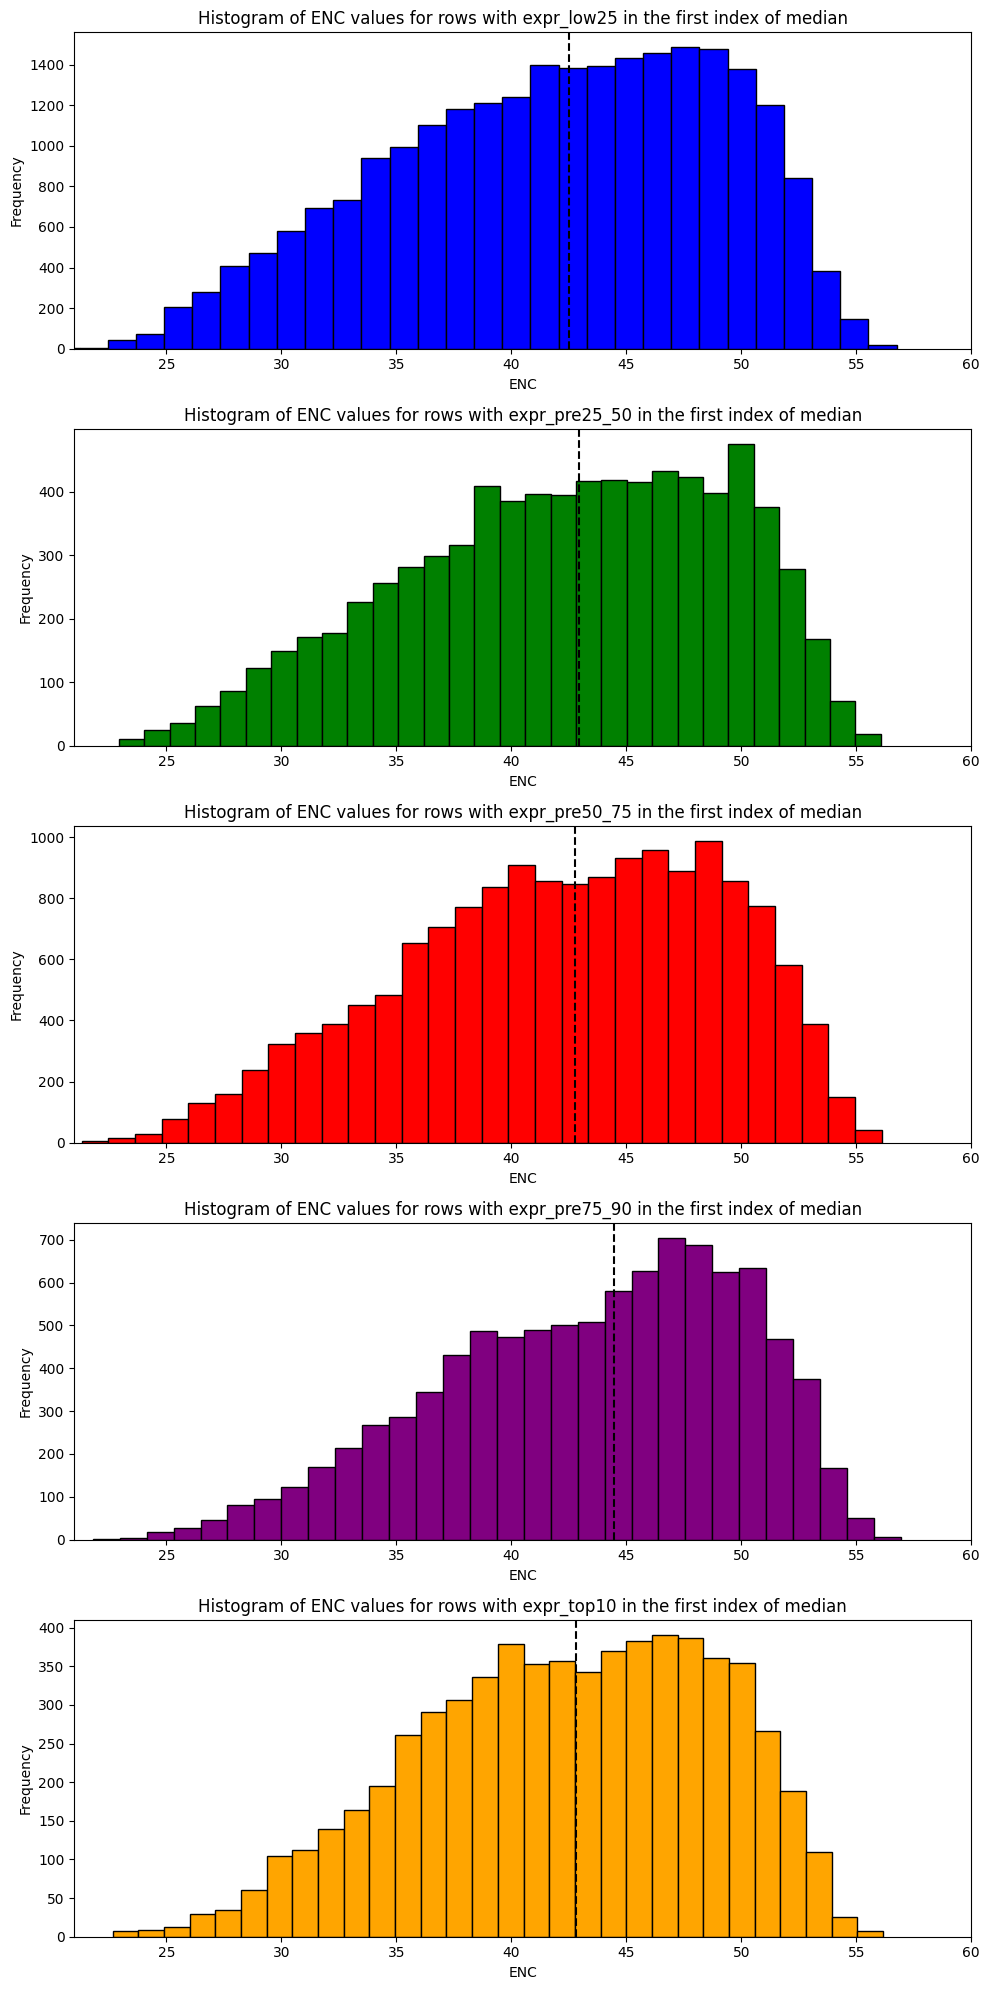

In [3]:
labels = ['expr_low25', 'expr_pre25_50', 'expr_pre50_75', 'expr_pre75_90', 'expr_top10']
# Filter rows where the first index of 'median' is 'expr_top10'
no_na_disc_df = discretized_df.dropna()
fig, axes = plt.subplots(nrows=len(labels), ncols=1, figsize=(10, 20))

colors = ['blue', 'green', 'red', 'purple', 'orange']

for ax, label, color in zip(axes, labels, colors):
    filtered_df = no_na_disc_df[no_na_disc_df['median'].apply(lambda x: x[0] == label)]
    ax.axvline(x=filtered_df['ENC'].median(), color='black', linestyle='dashed')
    # Plot histogram of the ENC values
    ax.hist(filtered_df['ENC'], bins=30, edgecolor='black', color=color)
    ax.set_xlabel('ENC')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Histogram of ENC values for rows with {label} in the first index of median')
    ax.set_xlim([21, 60])
    
plt.tight_layout()
plt.show()

## Graph Expression

### Mean Expression Histogram

In [3]:
# Calculate the mean values of the 'median_float' column
mean_exp_values = discretized_df['median_float'].dropna().apply(np.mean)

# --------------------

# Extract the same-length percentile vectors from the 'median_float' column
percentile_vectors = np.array(discretized_df['median'].dropna().tolist())

# Substitue percentile values with their corresponding integer values
percentiles = ["expr_low25", "expr_pre25_50", "expr_pre50_75", "expr_pre75_90", "expr_top10"]
percentile_dict = {percentiles[i]: i for i in range(len(percentiles))}
percentile_vectors = np.vectorize(lambda x: percentile_dict[x])(percentile_vectors)

# Calculate the mean values of the percentile vectors
mean_percentile_values = np.mean(percentile_vectors, axis=1)

# --------------------

num_bins = 30

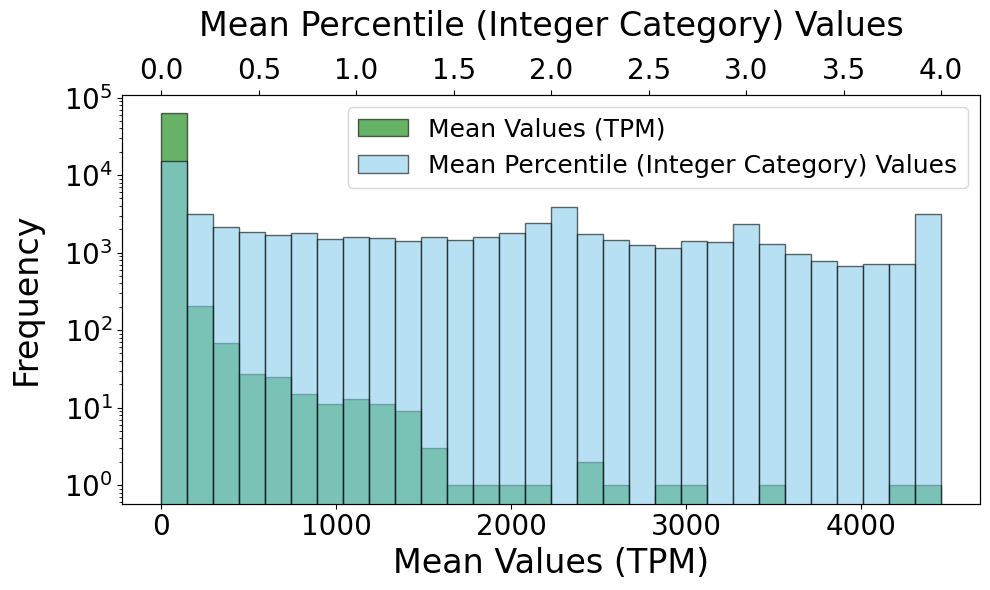

In [5]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the histogram of mean expression float-values on the first x-axis
ax1.hist(mean_exp_values, bins=num_bins, edgecolor='black', color='green', alpha=0.6, label='Mean Values (TPM)')
ax1.set_xlabel('Mean Values (TPM)', fontsize=24)
ax1.set_ylabel('Frequency', fontsize=24, labelpad=15)
ax1.tick_params(labelsize=20)
ax1.set_yscale('log')

# Create a twin x-axis for the second histogram
ax2 = ax1.twiny()
ax2.hist(mean_percentile_values, bins=num_bins, edgecolor='black', color='skyblue', alpha=0.6, label='Mean Percentile (Integer Category) Values')
ax2.set_xlabel('Mean Percentile (Integer Category) Values', fontsize=24, labelpad=15)
ax2.tick_params(labelsize=20)

# Add a legend
fig.legend(fontsize=18, loc='upper right', bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)

plt.tight_layout()

# Save the figure as an SVG file
fig.savefig('mean_expression_combined_histogram.svg', format='svg', transparent=True, bbox_inches='tight')

plt.show()


### Covariance

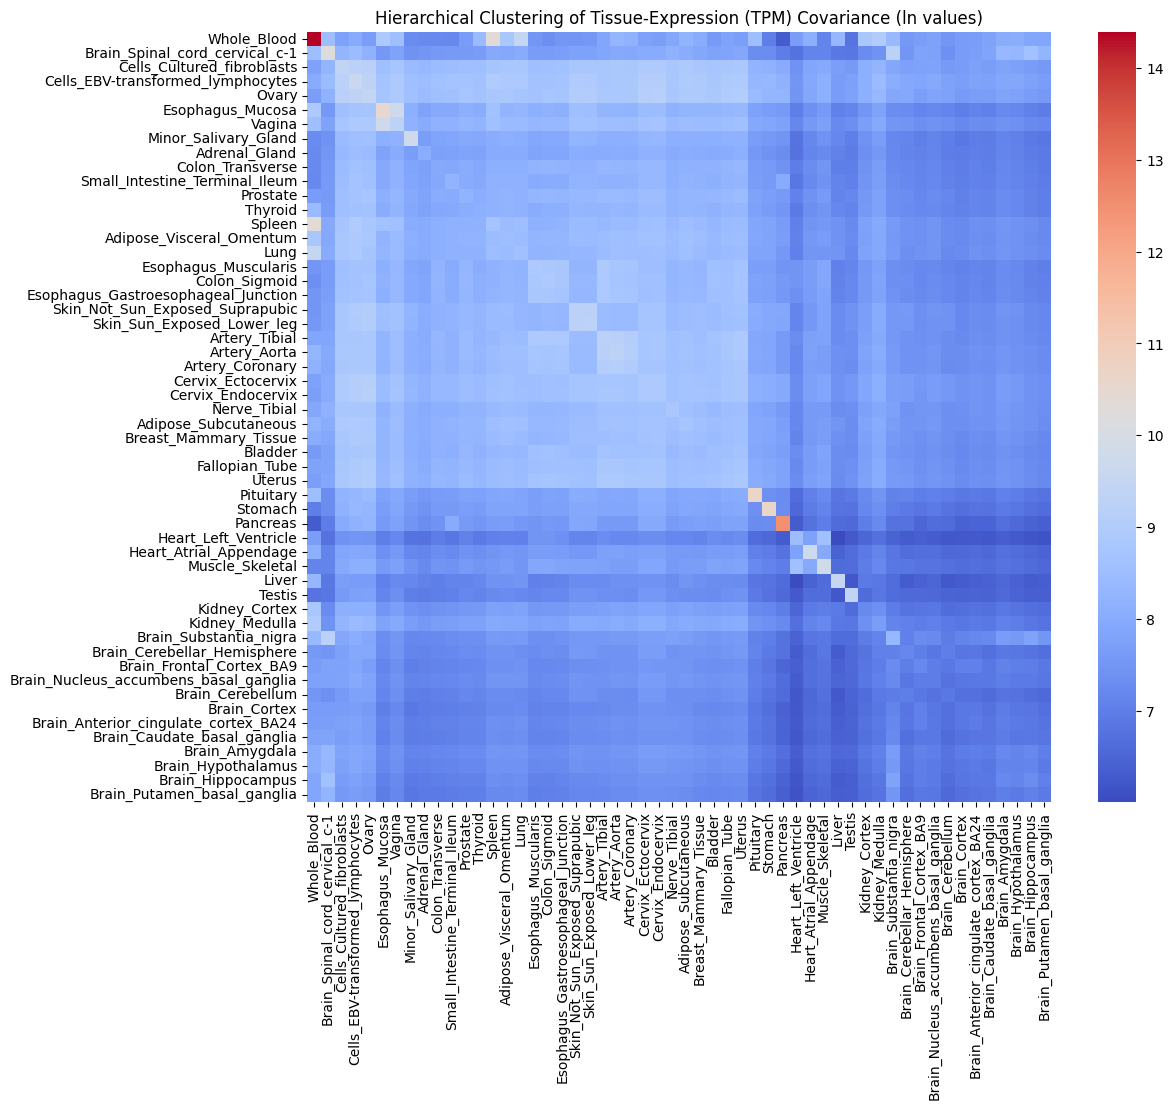

In [48]:
# Extract the same-length float vectors from the 'median_float' column
float_vectors = np.array(discretized_df['median_float'].dropna().tolist())

# Calculate the covariance matrix
cov_matrix = np.log(np.cov(float_vectors, rowvar=False))

# Compute the linkage matrix
linkage_matrix = linkage(cov_matrix, method='average')

# Extract the index ordering from the linkage matrix
cov_index_order = leaves_list(linkage_matrix)

# Reorder the correlation matrix using the extracted index ordering
reordered_cov_matrix = cov_matrix[cov_index_order, :][:, cov_index_order]

# Extract the first vector value in the column 'tissueSiteDetailID' for labeling
tick_labels = discretized_df.loc[0, 'tissueSiteDetailId']

# Reorder the tick labels
reordered_tick_labels = [tick_labels[i] for i in cov_index_order]

# Create a heatmap of the covariance matrix
plt.figure(figsize=(12, 10))
sns.heatmap(reordered_cov_matrix, cmap='coolwarm', xticklabels=reordered_tick_labels, yticklabels=reordered_tick_labels)
plt.title('Hierarchical Clustering of Tissue-Expression (TPM) Covariance (ln values)')
plt.show()

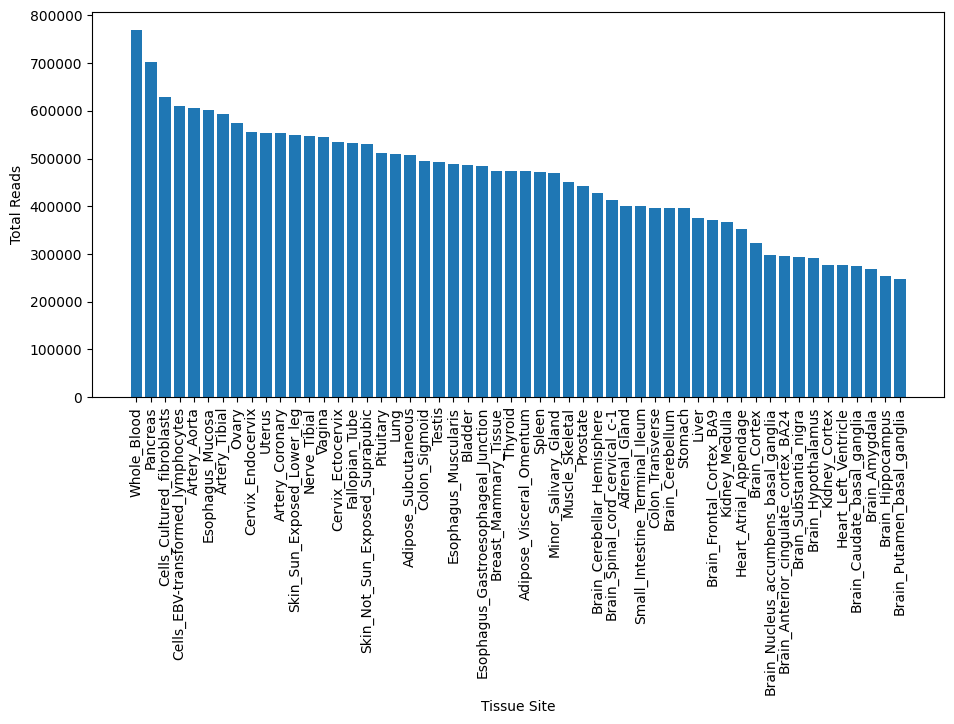

In [49]:
total_reads = np.stack(discretized_df['median_float'].dropna().tolist()).T.sum(axis=-1)
tissues = discretized_df.loc[0, 'tissueSiteDetailId']
# sort total reads and tissues by total reads
sorted_total_reads, sorted_tissues = zip(*sorted(zip(total_reads, tissues), reverse=True))

# histogram of total reads per tissue where x ticks are the tissues

# Create a colormap
# cmap = plt.get_cmap('coolwarm_r')

# Normalize the total_reads values to the range [0, 1]
# norm = mcolors.Normalize(vmin=0, vmax=len(total_reads) - 1)

# Create a list of colors based on the normalized values
# colors = [cmap(norm(i)) for i in range(len(total_reads))]

# Histogram of total reads per tissue where x ticks are the tissues
plt.figure(figsize=(11, 5))
plt.bar(sorted_tissues, sorted_total_reads)
plt.xticks(rotation=90)
plt.ylabel('Total Reads')
plt.xlabel('Tissue Site')
# plt.title('Total Reads per Tissue')

# Save the figure as an SVG file
plt.savefig('total_reads_per_tissue.svg', format='svg', transparent=True, bbox_inches='tight')

plt.show()

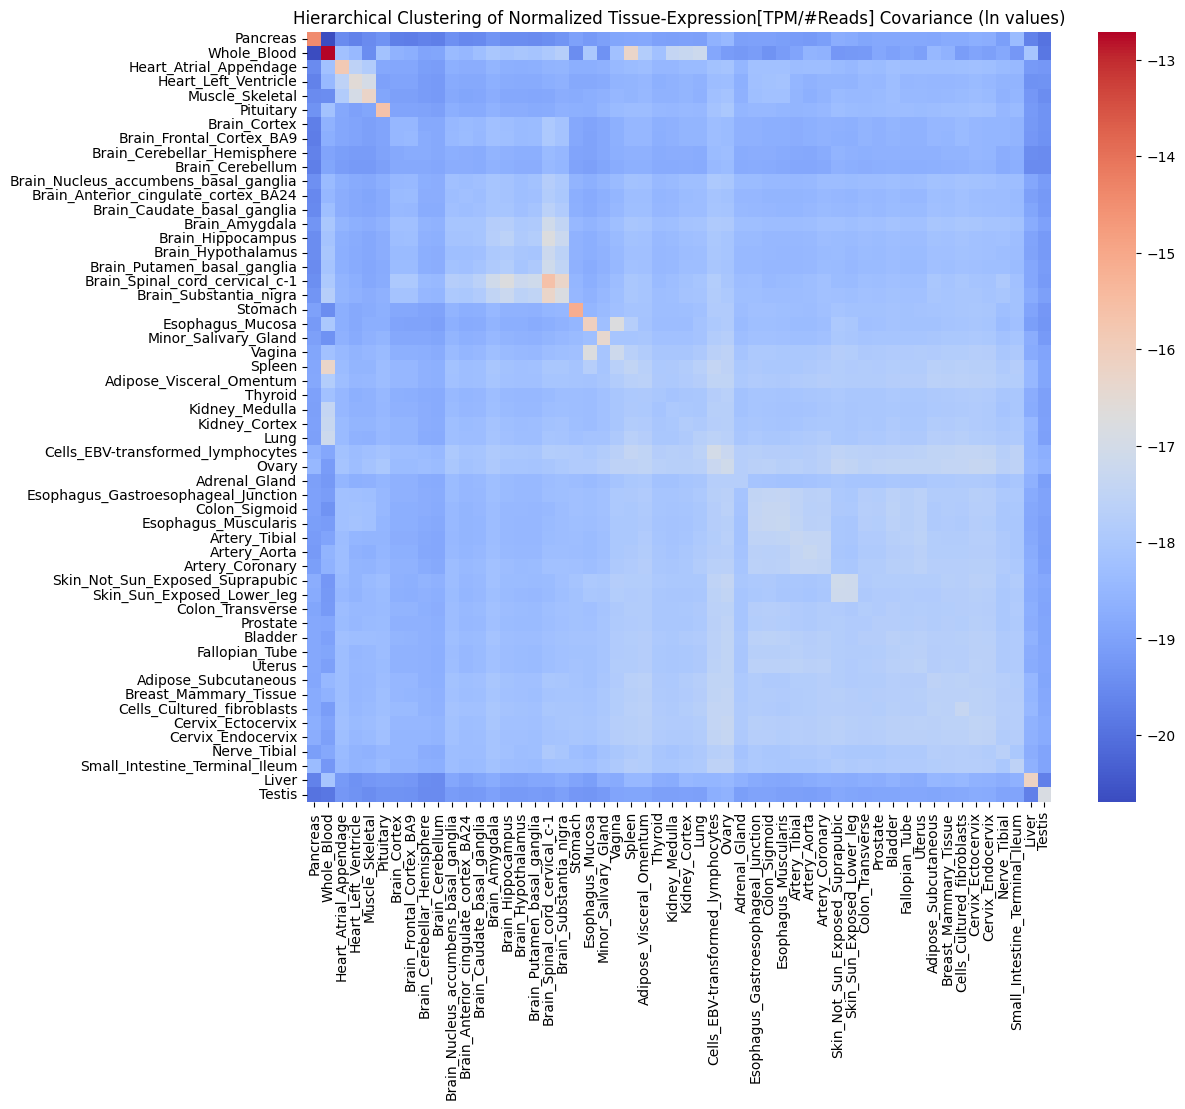

In [50]:
# Extract the same-length float vectors from the 'median_float' column
float_vectors = np.array(discretized_df['median_float'].dropna().tolist())

# Normalize the float vectors (shape [num_vectors, 54]) by the total reads (shape [54])
normalized_float_vectors = float_vectors / total_reads

# You know what this does.
cov_matrix = np.log(np.cov(normalized_float_vectors, rowvar=False))

# Compute the linkage matrix
linkage_matrix = linkage(cov_matrix, method='average')

# Extract the index ordering from the linkage matrix
cov_index_order = leaves_list(linkage_matrix)

# Reorder the correlation matrix using the extracted index ordering
reordered_cov_matrix_orig = cov_matrix[cov_index_order, :][:, cov_index_order]

# Extract the first vector value in the column 'tissueSiteDetailID' for labeling
tick_labels = discretized_df.loc[0, 'tissueSiteDetailId']

# Reorder the tick labels
reordered_tick_labels = [tick_labels[i] for i in cov_index_order]

# Create a heatmap of the covariance matrix
plt.figure(figsize=(12, 10))
sns.heatmap(reordered_cov_matrix_orig, cmap='coolwarm', xticklabels=reordered_tick_labels, yticklabels=reordered_tick_labels)
plt.title('Hierarchical Clustering of Normalized Tissue-Expression[TPM/#Reads] Covariance (ln values)')
plt.show()

In [51]:
# Extract the same-length float expression vectors from the 'median_float' column
float_vectors = discretized_df[['gene', 'median_float']].dropna()

# Explode 'median_float' into new columns
exploded_df = pd.DataFrame(float_vectors['median_float'].tolist(), index=float_vectors.index)

# Rename the columns to correspond to the tissue names
exploded_df.columns = tissues

# Concatenate the original 'gene' column with the exploded dataframe
exploded_df = pd.concat([float_vectors['gene'], exploded_df], axis=1)

exploded_df.set_index('gene', inplace=True)

In [52]:
# Extract the list of Ensembl gene IDs from the dataframe
ensembl_ids = top_5_genes.index

# Query mygene to get gene names
gene_info = mg.querymany(ensembl_ids, scopes='ensembl.gene', fields='symbol', species='human')

gene_names = [item['symbol'] for item in gene_info if 'symbol' in item]

# Create a bar plot of the top 5 genes in Whole_Blood
plt.figure(figsize=(10, 6))
plt.bar(gene_names, top_5_genes['Whole_Blood'], color='skyblue')
plt.xticks(rotation=45)
plt.ylabel('Expression (TPM)')
plt.title('Top 5 Genes in Whole_Blood')
plt.show()

NameError: name 'top_5_genes' is not defined

In [ ]:
float_vectors['Whole']

In [ ]:
temp_df = pd.DataFrame(normalized_float_vectors, columns=tissues)

In [ ]:
temp_df.max(axis=0).sort_values(ascending=False)

Whole_Blood                              0.293535
Pancreas                                 0.103330
Brain_Spinal_cord_cervical_c-1           0.088494
Stomach                                  0.084800
Heart_Atrial_Appendage                   0.081182
Pituitary                                0.073897
Esophagus_Mucosa                         0.049320
Muscle_Skeletal                          0.044790
Brain_Substantia_nigra                   0.043431
Liver                                    0.041343
Testis                                   0.038659
Heart_Left_Ventricle                     0.038173
Minor_Salivary_Gland                     0.035745
Cells_EBV-transformed_lymphocytes        0.026560
Brain_Hippocampus                        0.024147
Skin_Sun_Exposed_Lower_leg               0.021647
Vagina                                   0.020340
Skin_Not_Sun_Exposed_Suprapubic          0.018663
Artery_Aorta                             0.018272
Artery_Tibial                            0.017633


In [ ]:
temp_df['Whole_Blood'].argmax()

np.int64(61770)

In [ ]:
temp_df.loc[61770, 'Whole_Blood']

np.float64(0.29353545935250464)

In [ ]:
discretized_df.loc[61770, 'gene']

'ENSG00000175334'

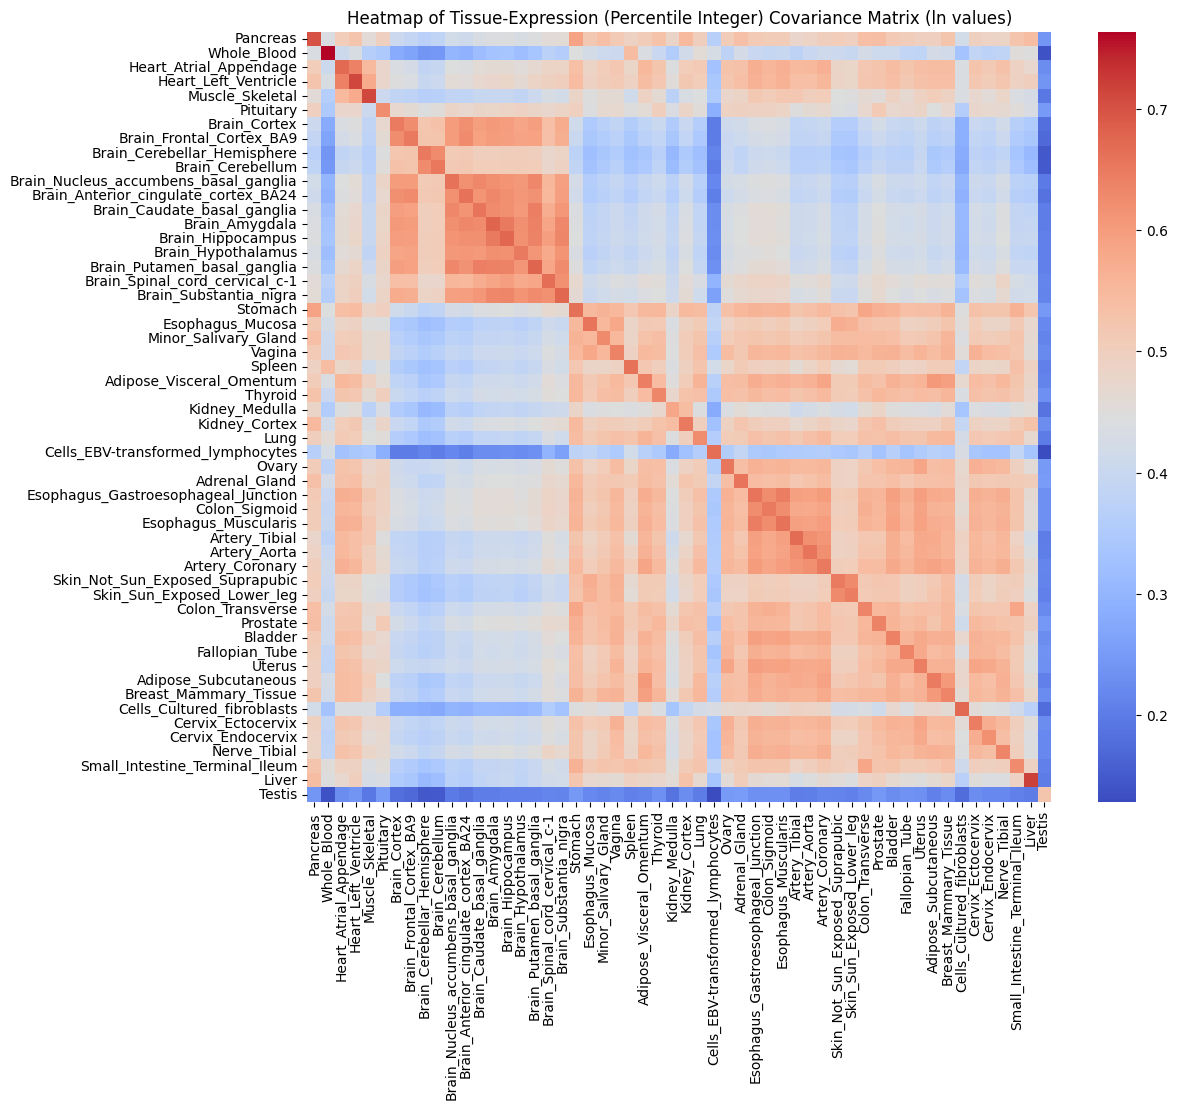

In [ ]:
# Extract the same-length percentile vectors from the 'median_float' column
percentile_vectors = np.array(discretized_df['median'].dropna().tolist())

# Substitue percentile values with their corresponding integer values
percentiles = ["expr_low25", "expr_pre25_50", "expr_pre50_75", "expr_pre75_90", "expr_top10"]
percentile_dict = {percentiles[i]: i for i in range(len(percentiles))}
percentile_vectors = np.vectorize(lambda x: percentile_dict[x])(percentile_vectors)

# Calculate the covariance matrix
cov_matrix = np.log(np.cov(percentile_vectors, rowvar=False))

# Reorder the correlation matrix using the extracted index ordering
reordered_cov_matrix = cov_matrix[cov_index_order, :][:, cov_index_order]

# Extract the first vector value in the column 'tissueSiteDetailID' for labeling
tick_labels = discretized_df.loc[0, 'tissueSiteDetailId']

# Reorder the tick labels
reordered_tick_labels = [tick_labels[i] for i in cov_index_order]

# Create a heatmap of the covariance matrix
plt.figure(figsize=(12, 10))
sns.heatmap(reordered_cov_matrix, cmap='coolwarm', xticklabels=reordered_tick_labels, yticklabels=reordered_tick_labels)
plt.title('Heatmap of Tissue-Expression (Percentile Integer) Covariance Matrix (ln values)')
plt.show()

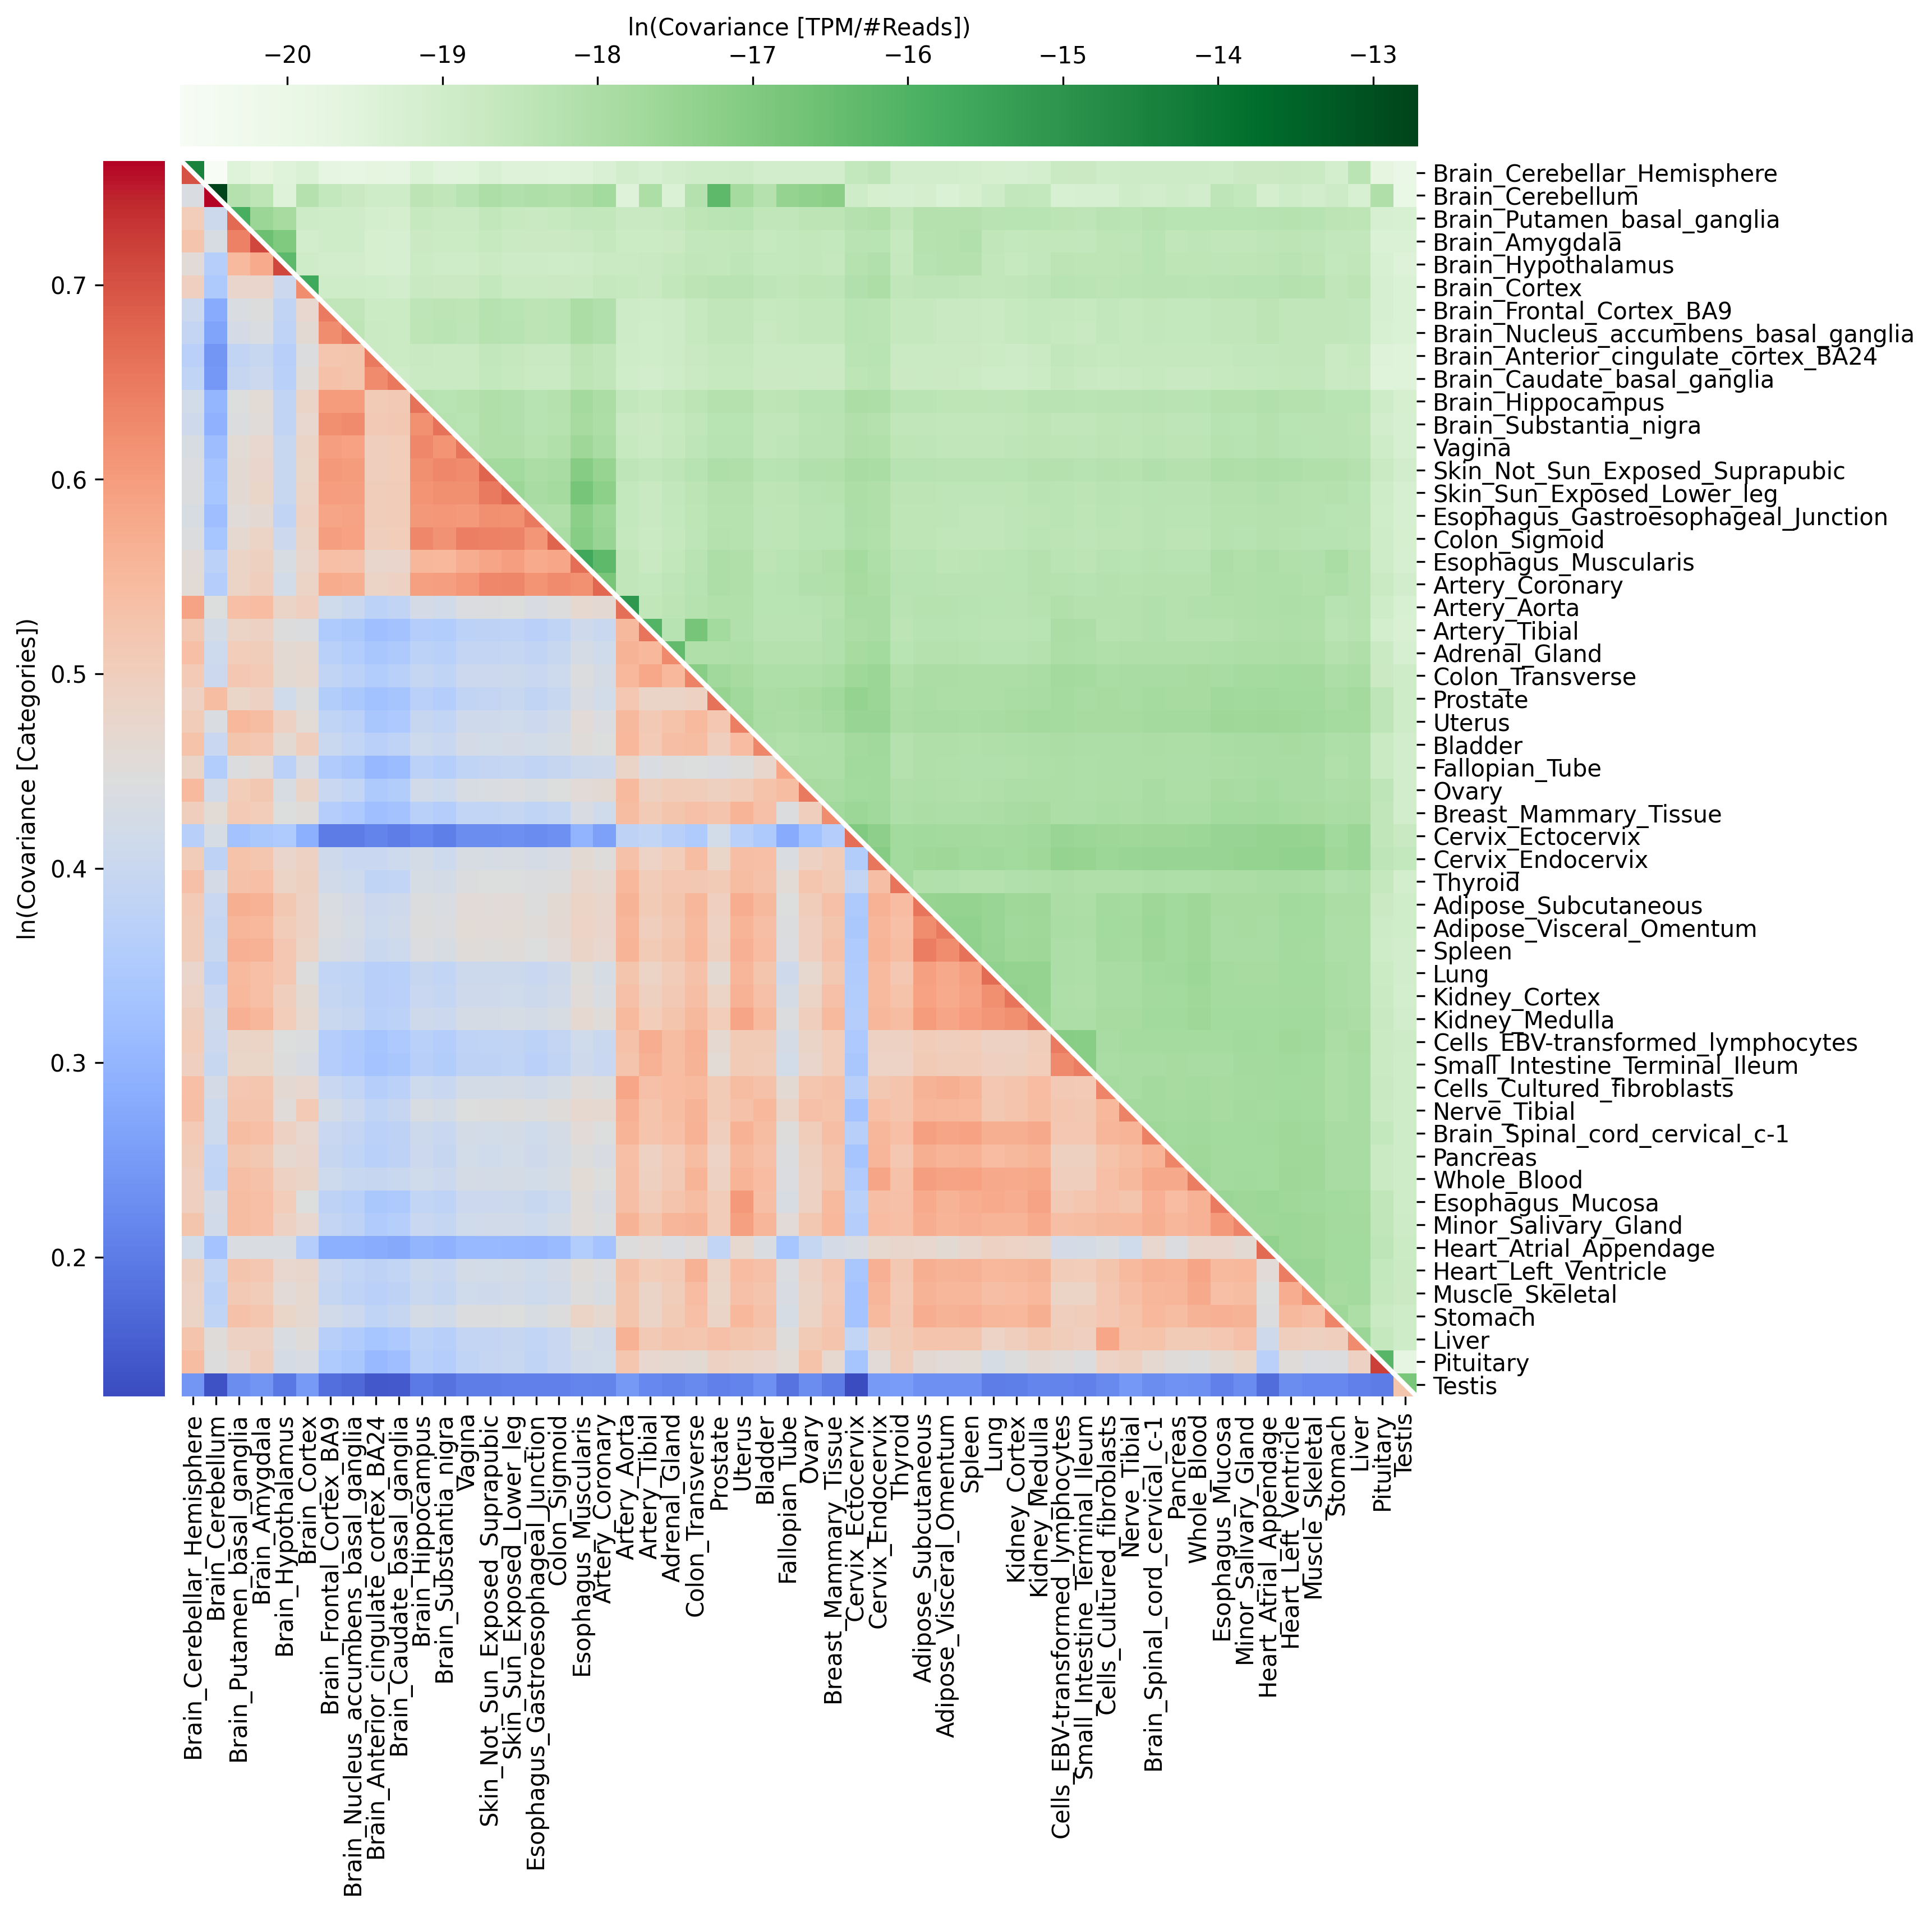

In [ ]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 12), dpi=300)

# lower heatmap
sns.heatmap(reordered_cov_matrix, ax=ax, cmap='coolwarm', cbar=True, square=True, xticklabels=False, yticklabels=False, mask=np.triu(np.ones_like(reordered_cov_matrix_orig), k=1), cbar_kws={"anchor": (1, 0), "shrink": 0.84, "location": "left", "pad": 0.01})
lower_cmap = sns.color_palette("coolwarm", as_cmap=True)

# upper heatmap
sns.heatmap(reordered_cov_matrix_orig, ax=ax, cmap='Greens', cbar=True, square=True, xticklabels=False, yticklabels=False, mask=np.tril(np.ones_like(reordered_cov_matrix_orig), k=-1), cbar_kws={"shrink": 1, "location": "top", "pad": 0.01})

# Add diagonal white lines and color the upper half above each diagonal line
for i in range(len(reordered_cov_matrix)):
    # White line separator
    line = Line2D([i, i + 1], [i, i + 1], color='white', linewidth=2)

    # Lower heatmap diagonal coloring
    value = reordered_cov_matrix[i, i]
    norm_value = (value - np.min(reordered_cov_matrix)) / (np.max(reordered_cov_matrix) - np.min(reordered_cov_matrix))
    color = lower_cmap(norm_value)
    polygon = patches.Polygon([[i, i], [i, i + 1], [i + 1, i + 1]], closed=True, facecolor=color, edgecolor='none', linewidth=2)

    ax.add_patch(polygon)
    ax.add_line(line)

# Move y-tick labels to the right side
ax.yaxis.tick_right()
ax.yaxis.set_label_position('right')

# Set axis labels and title
ax.set_xticks(np.arange(len(reordered_tick_labels)) + 0.5)
ax.set_yticks(np.arange(len(reordered_tick_labels)) + 0.5)
ax.set_xticklabels(reordered_tick_labels, rotation=90)
ax.set_yticklabels(reordered_tick_labels)

# ax.set_title('Overlayed Heatmaps with Diagonal Split')

# Square proportions
ax.set_aspect('equal')

# make cbars smaller
cbar1 = ax.collections[0].colorbar
cbar2 = ax.collections[1].colorbar
# add cbar labels
cbar1.set_label('ln(Covariance [Categories])')
cbar2.set_label('ln(Covariance [TPM/#Reads])')
# position cbar1 to the left
cbar1.ax.yaxis.set_label_position('left')
cbar1.ax.yaxis.set_ticks_position('left')
# position cbar2 to the top
cbar2.ax.xaxis.set_label_position('top')
cbar2.ax.xaxis.set_ticks_position('top')

# Save the figure as an SVG file
fig.savefig('covariance_heatmaps.svg', format='svg', transparent=True, bbox_inches='tight')

plt.tight_layout()
plt.show()


### Correlation

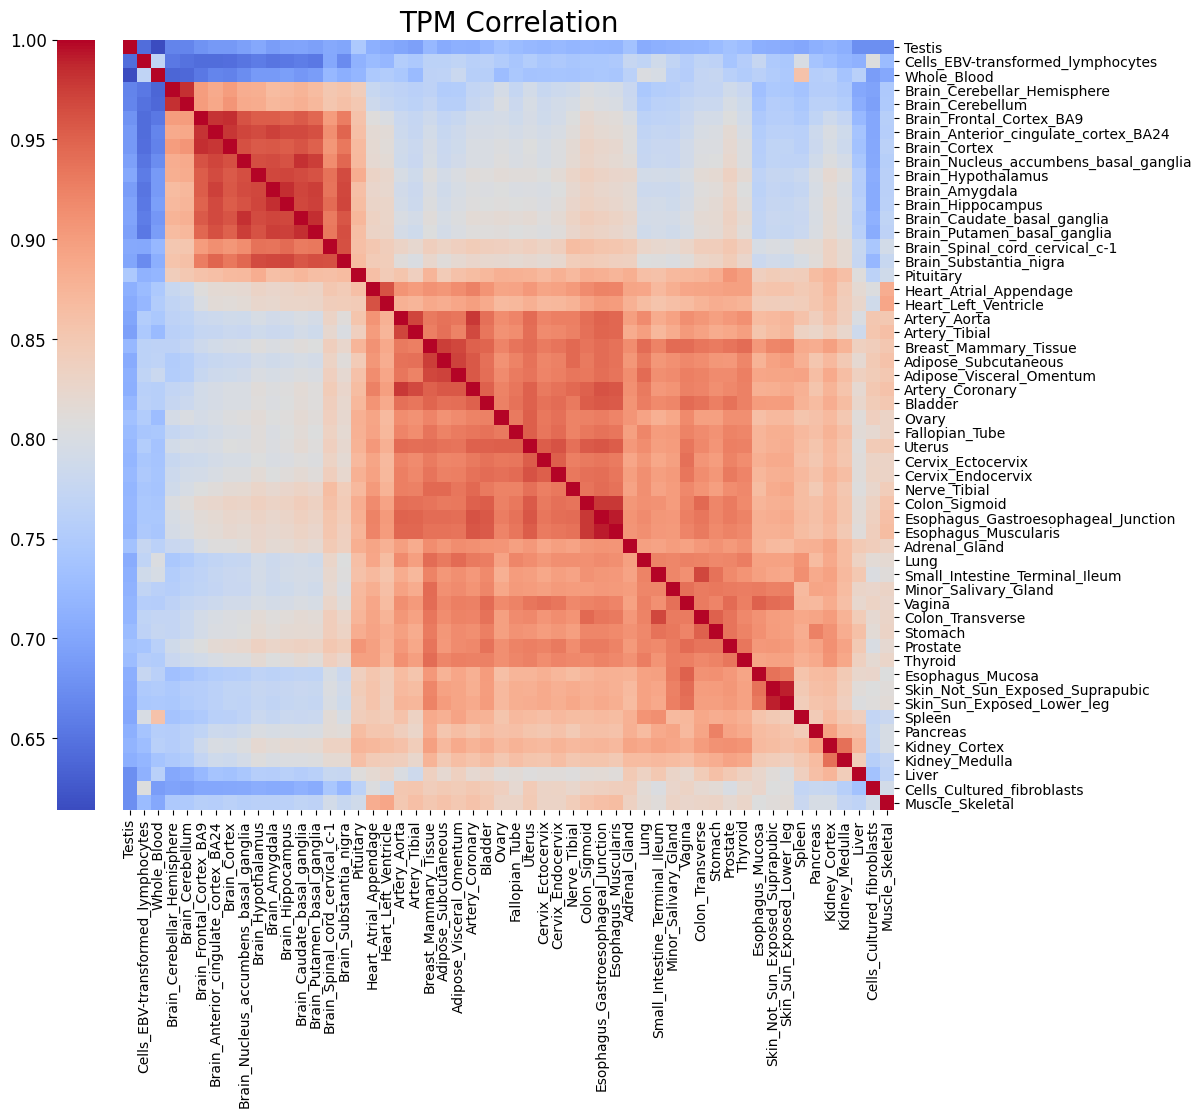

In [53]:
# Compute the Spearman correlation matrix
corr_matrix_1, _ = spearmanr(normalized_float_vectors, axis=0)

# Compute the linkage matrix
linkage_matrix = linkage(corr_matrix_1, method='average')

# Extract the index ordering from the linkage matrix
corr_index_order = leaves_list(linkage_matrix)

# Reorder the correlation matrix using the extracted index ordering
reordered_corr_matrix_1 = corr_matrix_1[corr_index_order, :][:, corr_index_order]

# Extract the first vector value in the column 'tissueSiteDetailID' for labeling
tick_labels = discretized_df.loc[0, 'tissueSiteDetailId']

# Reorder the tick labels
reordered_tick_labels = [tick_labels[i] for i in corr_index_order]

# Plot the reordered heatmap with the color bar on the left
plt.figure(figsize=(12, 10))
ax = sns.heatmap(reordered_corr_matrix_1, cmap='coolwarm', xticklabels=reordered_tick_labels, yticklabels=reordered_tick_labels, cbar_kws={'orientation': 'vertical', 'pad': 0.02})

# Change the position of the color bar to the left
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_ticks_position('left')
cbar.ax.yaxis.set_label_position('left')
cbar.ax.set_position([0.07, cbar.ax.get_position().y0, cbar.ax.get_position().width, cbar.ax.get_position().height])
# set the colorbar label size
cbar.ax.tick_params(labelsize=12)

# Swap y-ticks and y-labels
ax.yaxis.tick_right()
ax.yaxis.set_label_position('right')

# Rotate y-tick labels to be horizontal
plt.yticks(rotation=0)

plt.title('TPM Correlation', fontsize=20)

# Save the figure as an SVG file without cutting off the labels and with transparent background
# plt.savefig('hierarchical_heatmap_correlation.svg', bbox_inches='tight', transparent=True)

plt.show()


In [154]:
percentile_vectors

array([[4, 4, 4, ..., 4, 4, 2],
       [2, 2, 2, ..., 2, 2, 0],
       [4, 3, 0, ..., 1, 1, 0],
       ...,
       [0, 0, 0, ..., 1, 1, 0],
       [2, 2, 2, ..., 2, 2, 3],
       [0, 0, 0, ..., 0, 0, 0]])

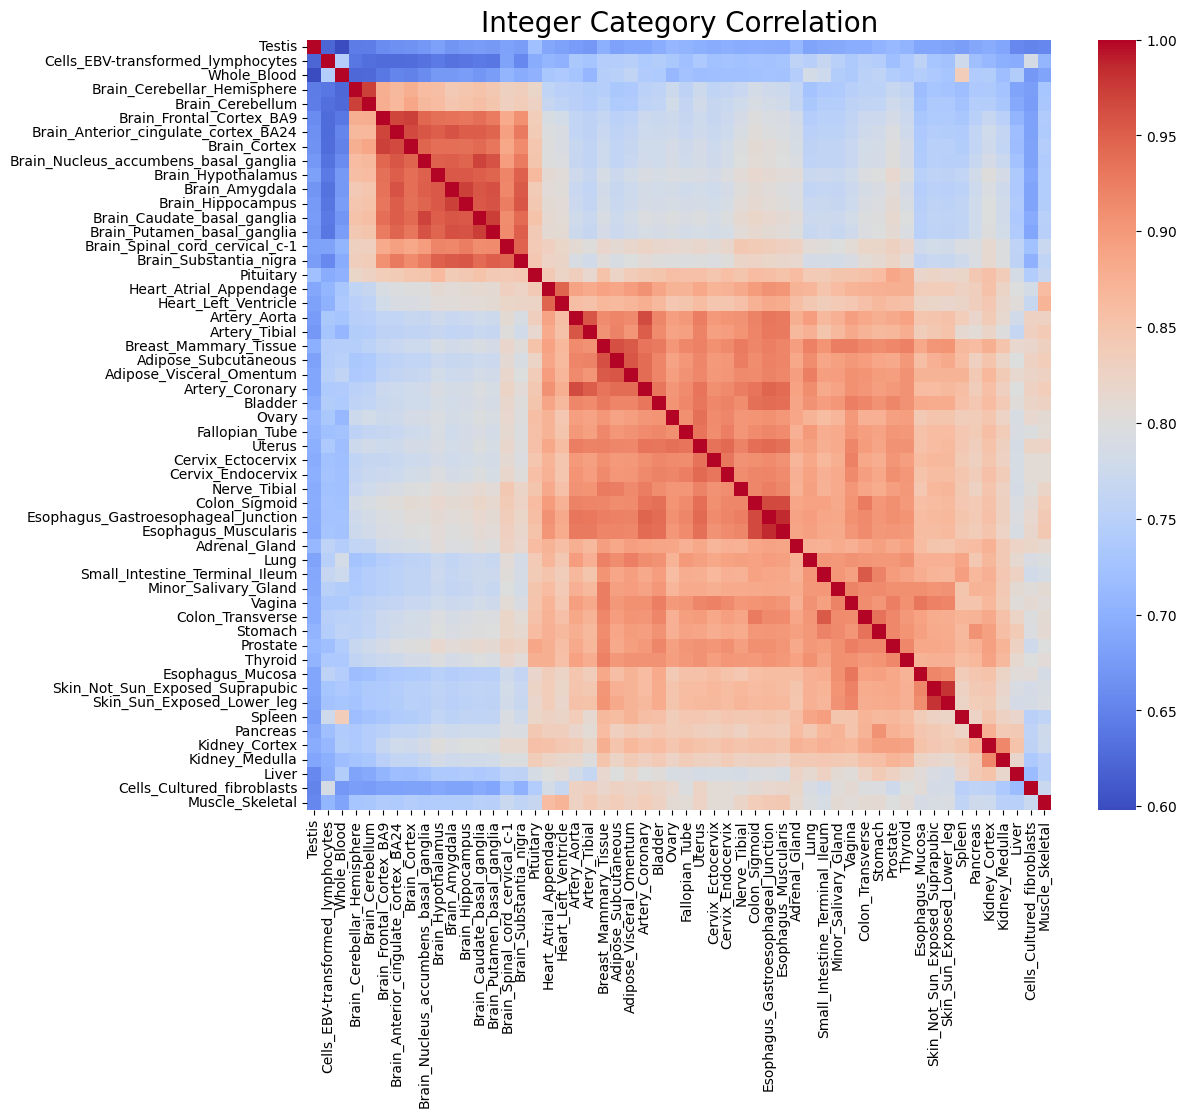

In [54]:
# Extract the same-length percentile vectors from the 'median_float' column
percentile_vectors = np.array(discretized_df['median'].dropna().tolist())

# Substitue percentile values with their corresponding integer values
percentiles = ["expr_low25", "expr_pre25_50", "expr_pre50_75", "expr_pre75_90", "expr_top10"]
percentile_dict = {percentiles[i]: i for i in range(len(percentiles))}
percentile_vectors = np.vectorize(lambda x: percentile_dict[x])(percentile_vectors)

# Calculate the correlation matrix
corr_matrix_2, _ = spearmanr(percentile_vectors, axis=0)

# Reorder the correlation matrix using the extracted index ordering
reordered_corr_matrix_2 = corr_matrix_2[corr_index_order, :][:, corr_index_order]

# Extract the first vector value in the column 'tissueSiteDetailID' for labeling
tick_labels = discretized_df.loc[0, 'tissueSiteDetailId']

# Reorder the tick labels
reordered_tick_labels = [tick_labels[i] for i in corr_index_order]

# Plot the reordered heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(reordered_corr_matrix_2, cmap='coolwarm', xticklabels=reordered_tick_labels, yticklabels=reordered_tick_labels)

plt.title('Integer Category Correlation', fontsize=20)

# Save the figure as an SVG file
# fig.savefig('percentile_heatmap_correlation.svg', format='svg', transparent=True, bbox_inches='tight')

plt.show()

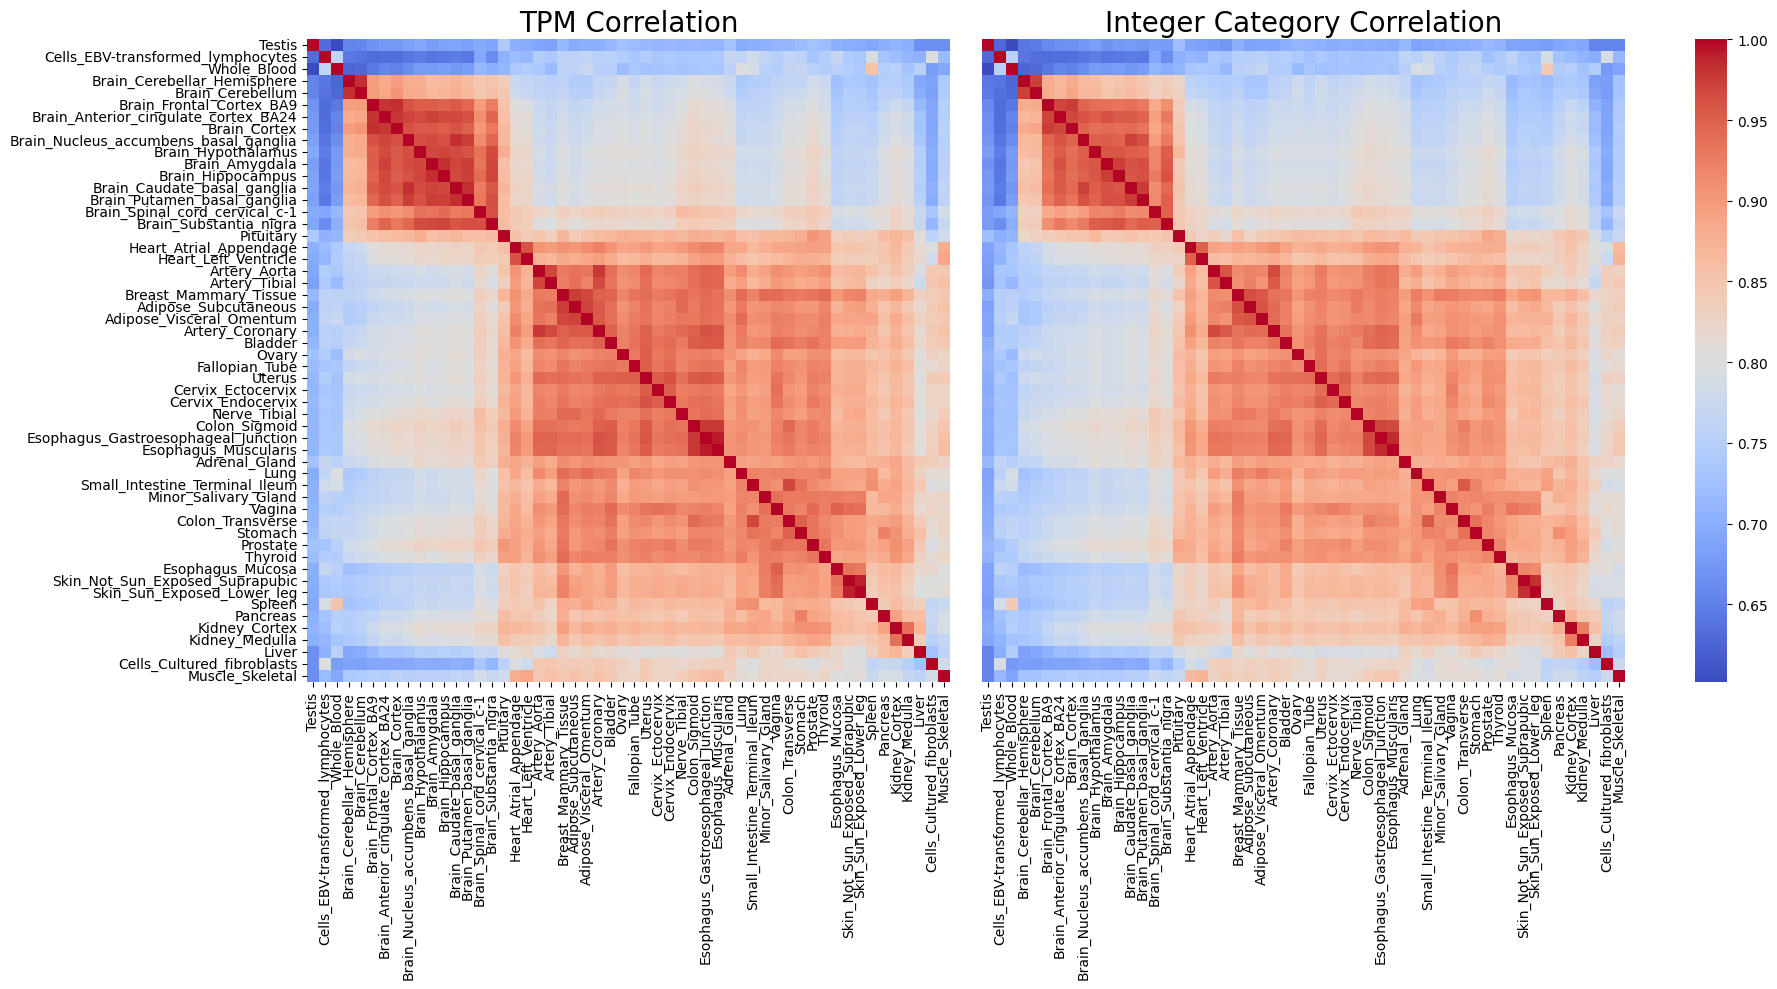

In [146]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(24, 10))

# Plot the first heatmap
sns.heatmap(reordered_corr_matrix_1, cmap='coolwarm', xticklabels=reordered_tick_labels, yticklabels=reordered_tick_labels, ax=axes[0])
axes[0].set_title('TPM Correlation', fontsize=20)
# remove color bar
axes[0].collections[0].colorbar.remove()
# width = height
axes[0].set_aspect('equal')

# Plot the second heatmap
sns.heatmap(reordered_corr_matrix_2, cmap='coolwarm', xticklabels=reordered_tick_labels, yticklabels=[], ax=axes[1])
axes[1].set_title('Integer Category Correlation', fontsize=20)
axes[1].set_aspect('equal')

# make the two axes closer
plt.subplots_adjust(wspace=-0.8)

plt.tight_layout()

# Save the figure as an SVG file
# fig.savefig('correlation_heatmaps.svg', format='svg', transparent=True, bbox_inches='tight')

plt.show()

In [157]:
reordered_corr_matrix_2 - reordered_corr_matrix_1

array([[ 0.00000000e+00, -2.18341887e-02, -1.59322738e-02, ...,
        -1.98642119e-02, -2.42203073e-02, -2.06946980e-02],
       [-2.18341887e-02,  0.00000000e+00, -2.31151068e-02, ...,
        -1.88030732e-02, -1.87534584e-02, -1.89613647e-02],
       [-1.59322738e-02, -2.31151068e-02,  0.00000000e+00, ...,
        -1.63285573e-02, -1.89456657e-02, -1.56853147e-02],
       ...,
       [-1.98642119e-02, -1.88030732e-02, -1.63285573e-02, ...,
         2.22044605e-16, -2.05322133e-02, -1.77790997e-02],
       [-2.42203073e-02, -1.87534584e-02, -1.89456657e-02, ...,
        -2.05322133e-02,  0.00000000e+00, -2.03909675e-02],
       [-2.06946980e-02, -1.89613647e-02, -1.56853147e-02, ...,
        -1.77790997e-02, -2.03909675e-02,  2.22044605e-16]])

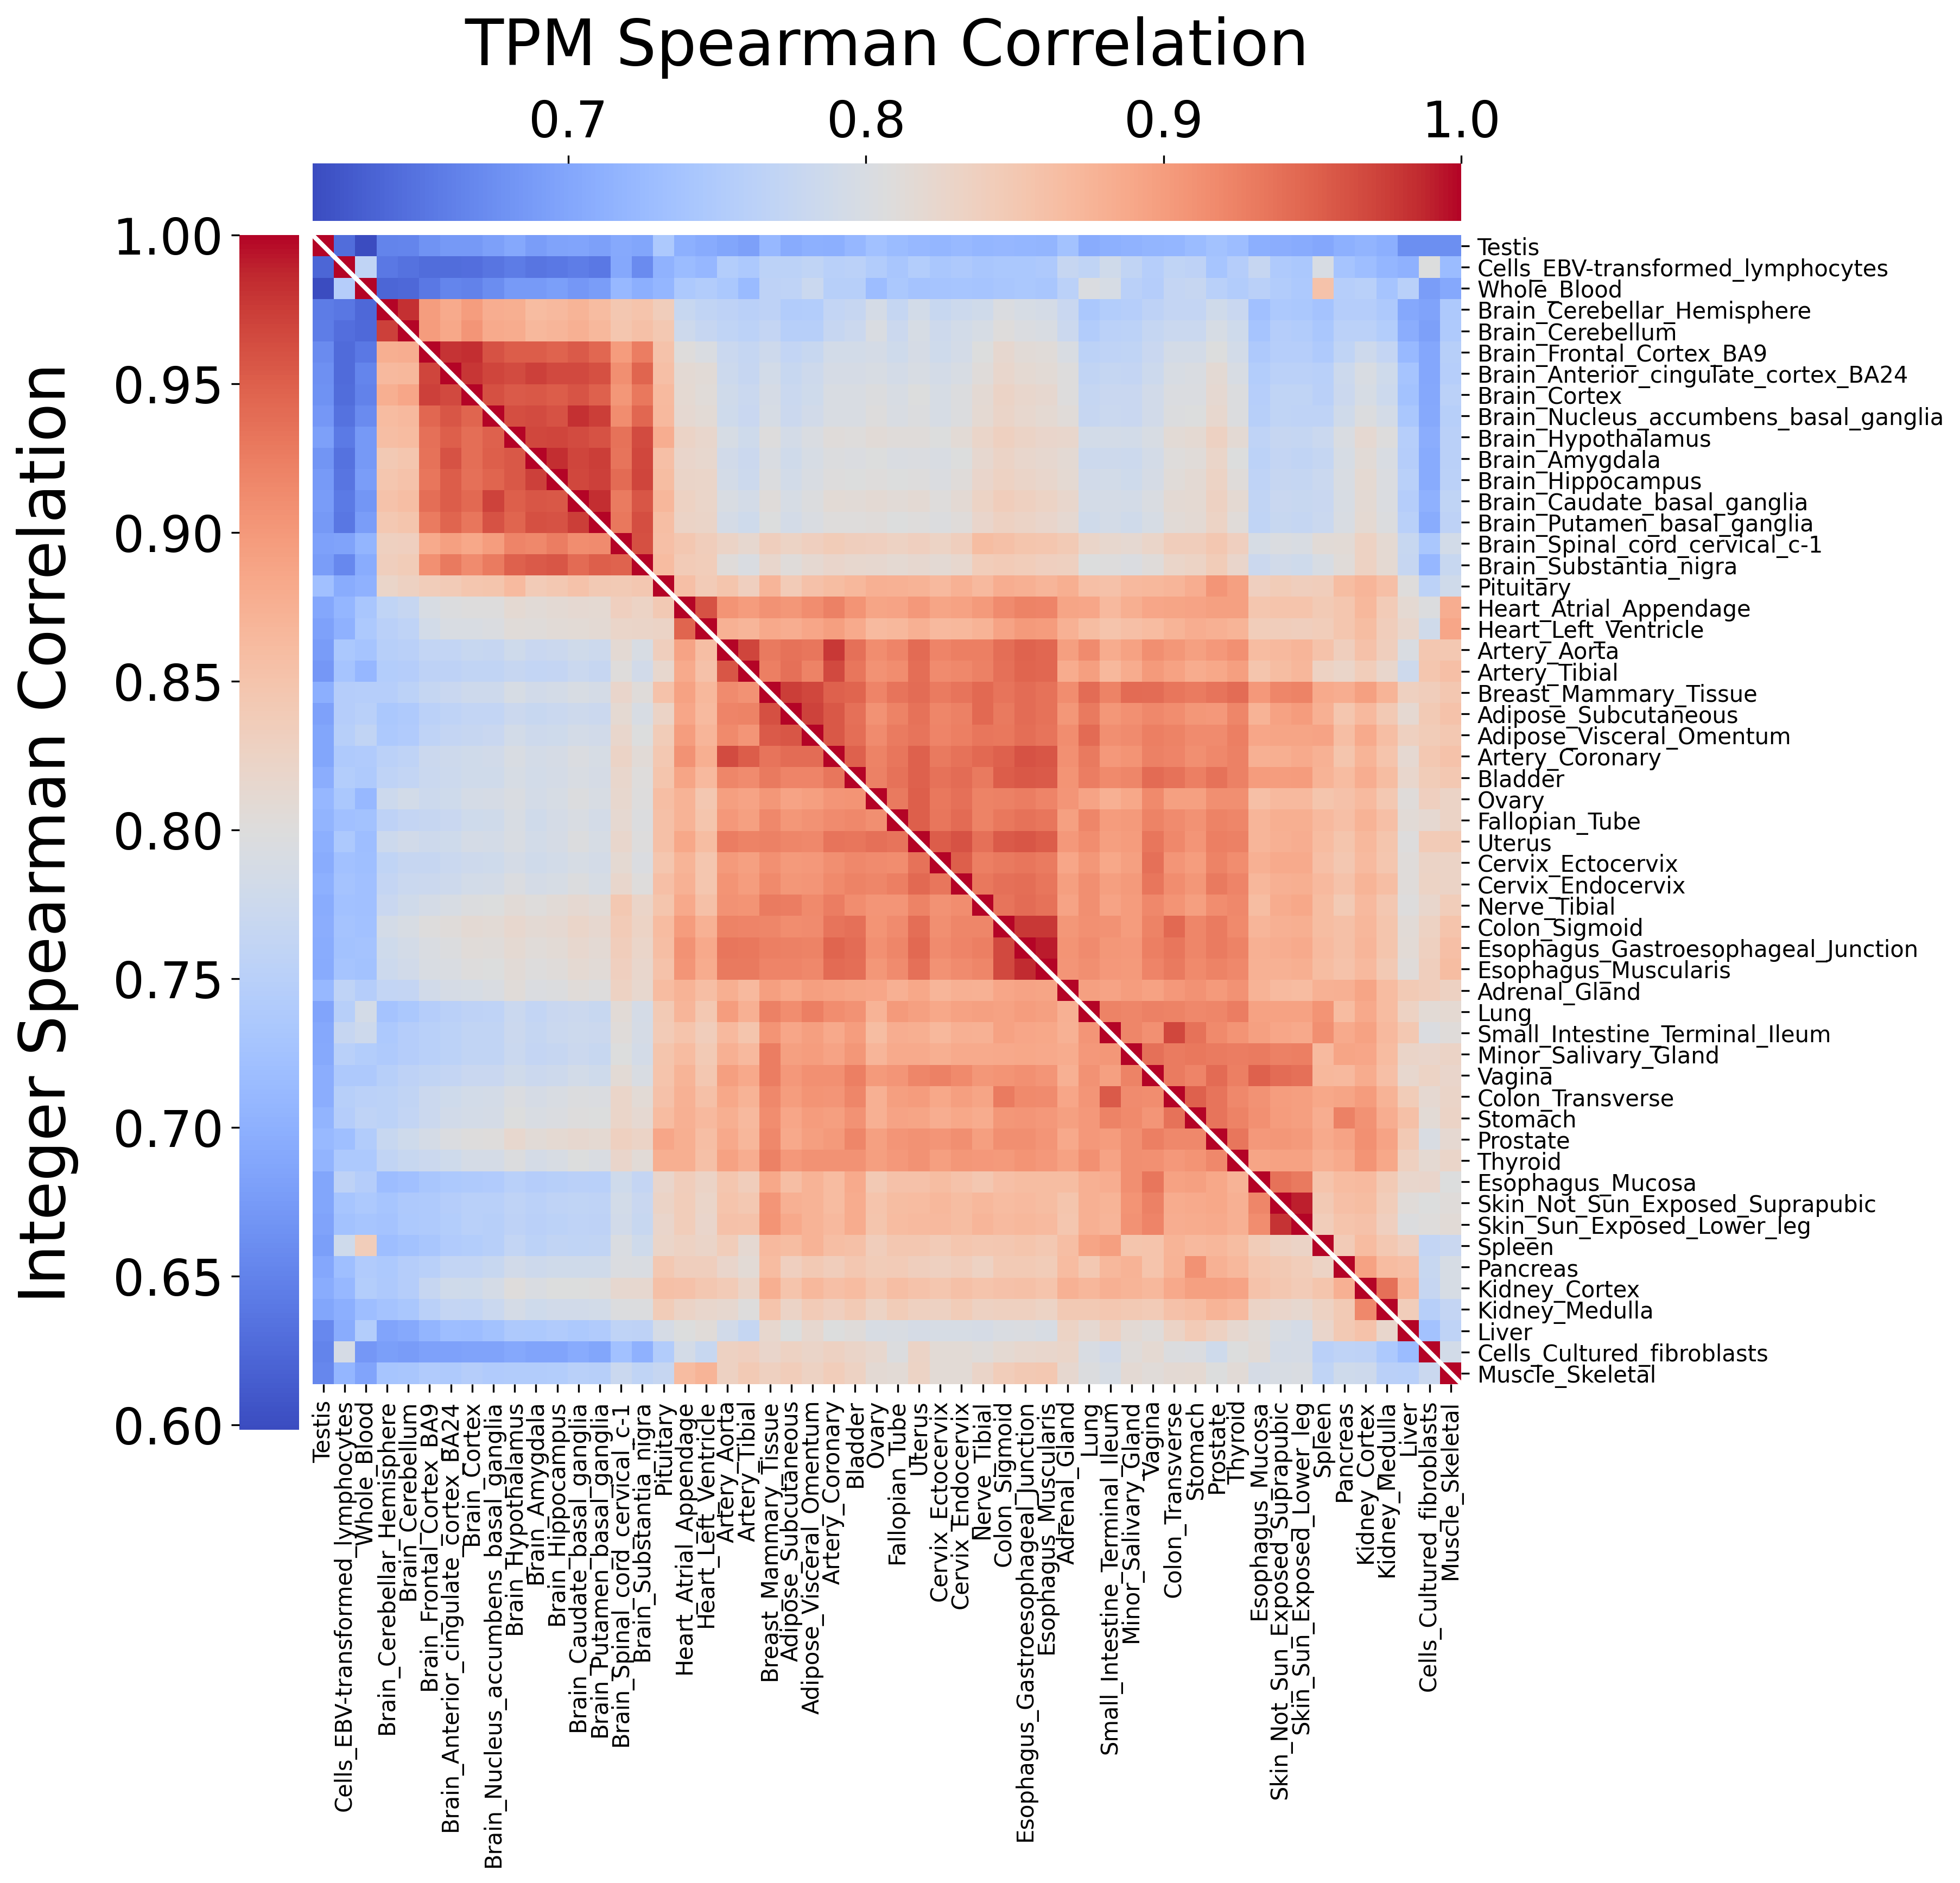

In [65]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 12), dpi=300)

# lower heatmap
sns.heatmap(reordered_corr_matrix_2, ax=ax, cmap='coolwarm', cbar=True, square=True, xticklabels=False, yticklabels=False, mask=np.triu(np.ones_like(reordered_cov_matrix_orig), k=1), cbar_kws={"anchor": (1, 0), "shrink": 0.84, "location": "left", "pad": 0.01})
lower_cmap = sns.color_palette("coolwarm", as_cmap=True)

# upper heatmap
sns.heatmap(reordered_corr_matrix_1, ax=ax, cmap='coolwarm', cbar=True, square=True, xticklabels=False, yticklabels=False, mask=np.tril(np.ones_like(reordered_cov_matrix_orig), k=-1), cbar_kws={"shrink": 1, "location": "top", "pad": 0.01})

# Add diagonal white lines and color the upper half above each diagonal line
for i in range(len(reordered_corr_matrix_2)):
    # White line separator
    line = Line2D([i, i + 1], [i, i + 1], color='white', linewidth=2)

    # Lower heatmap diagonal coloring
    value = reordered_corr_matrix_2[i, i]
    norm_value = (value - np.min(reordered_corr_matrix_2)) / (np.max(reordered_corr_matrix_2) - np.min(reordered_corr_matrix_2))
    color = lower_cmap(norm_value)
    polygon = patches.Polygon([[i, i], [i, i + 1], [i + 1, i + 1]], closed=True, facecolor=color, edgecolor='none', linewidth=2)

    ax.add_patch(polygon)
    ax.add_line(line)

# Move y-tick labels to the right side
ax.yaxis.tick_right()
ax.yaxis.set_label_position('right')

# Set axis labels and title
ax.set_xticks(np.arange(len(reordered_tick_labels)) + 0.5)
ax.set_yticks(np.arange(len(reordered_tick_labels)) + 0.5)
ax.set_xticklabels(reordered_tick_labels, rotation=90)
ax.set_yticklabels(reordered_tick_labels)

# ax.set_title('Overlayed Heatmaps with Diagonal Split')

# Square proportions
ax.set_aspect('equal')

# make cbars smaller
cbar1 = ax.collections[0].colorbar
cbar2 = ax.collections[1].colorbar
# add cbar labels
cbar1.set_label('Integer Spearman Correlation', fontsize=28, labelpad=15)
cbar2.set_label('TPM Spearman Correlation', fontsize=28, labelpad=15)
# position cbar1 to the left
cbar1.ax.yaxis.set_label_position('left')
cbar1.ax.yaxis.set_ticks_position('left')
# position cbar2 to the top
cbar2.ax.xaxis.set_label_position('top')
cbar2.ax.xaxis.set_ticks_position('top')
# cbar tick size
cbar1.ax.tick_params(labelsize=22)
cbar2.ax.tick_params(labelsize=22)

# Save the figure as an SVG file
fig.savefig('correlation_heatmaps.svg', format='svg', bbox_inches='tight')

plt.tight_layout()
plt.show()


In [160]:
frobenius_distance = np.linalg.norm(corr_matrix_1 - corr_matrix_2, 'fro')
print(f'Frobenius distance between the correlation matrices: {frobenius_distance}')

Frobenius distance between the correlation matrices: 1.0748148959115713


In [49]:
def herdin_distance(corr_matrix_1, corr_matrix_2):
    # Calculate the Frobenius norm of the difference between the two correlation matrices
    distance = 1 - np.trace(np.dot(corr_matrix_1, corr_matrix_2)) / np.sqrt(np.trace(np.dot(corr_matrix_1, corr_matrix_1)) * np.trace(np.dot(corr_matrix_2, corr_matrix_2)))
    return distance

herdin_dist = herdin_distance(corr_matrix_1, corr_matrix_2)
print(f'Herdin distance between the correlation matrices: {herdin_dist}')

Herdin distance between the correlation matrices: 0.12380200846678369


In [33]:
def normalized_frobenius_distance(matrix1, matrix2):
    frobenius_norm_1 = np.linalg.norm(matrix1, 'fro')
    frobenius_norm_2 = np.linalg.norm(matrix2, 'fro')
    frobenius_distance = np.linalg.norm(matrix1 - matrix2, 'fro')
    normalized_distance = frobenius_distance / (frobenius_norm_1 * frobenius_norm_2)
    return normalized_distance

normalized_frobenius_dist = normalized_frobenius_distance(corr_matrix_1, corr_matrix_2)
print(f'Normalized Frobenius distance between the correlation matrices: {normalized_frobenius_dist}')

Normalized Frobenius distance between the correlation matrices: 0.017125584117701122


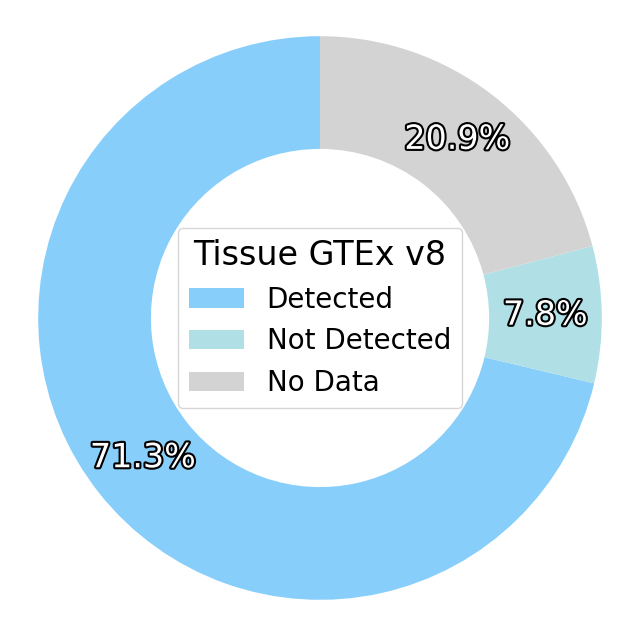

In [5]:
num_nan = discretized_df['median_float'].isna().sum()
num_all_zeros_rows = discretized_df['median_float'].apply(lambda x: np.all(np.array(x) == 0)).sum()
num_other = len(discretized_df) - num_nan - num_all_zeros_rows

# Pie chart
labels = ['Detected', 'Not Detected', 'No Data']
sizes = [num_other, num_all_zeros_rows, num_nan]
colors = ['lightskyblue', 'powderblue', 'lightgrey']

plt.figure(figsize=(8, 8))

# Adjust the startangle to change the orientation
wedges, texts, autotexts = plt.pie(sizes, colors=colors, autopct='%1.1f%%', startangle=90, textprops=dict(color="black"), wedgeprops=dict(width=0.4), pctdistance=0.8)
for autotext in autotexts:
    autotext.set_fontsize(24)
    autotext.set_color('white')
    # black border to text
    autotext.set_path_effects([pe.withStroke(linewidth=3, foreground='black')])
    
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Add a legend below the pie chart
plt.legend(wedges, labels, title="Tissue GTEx v8", loc="center", fontsize=20, title_fontsize=24)

# Save the figure as an SVG file
plt.savefig('pie_chart.svg', format='svg', transparent=True, bbox_inches='tight')

plt.show()